# Koopman Operator Training with EncoderDecoder

This notebook implements a training pipeline for EncoderDecoder model. The code includes data loading, model definition, training, and visualization of results such as trajectories and eigenvalues.


In [ ]:
import os
# Move up one directory to make sure the script can find the modules and save files in the correct place
os.chdir('..')
# Verify the current working directory
print(os.getcwd())

import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.init as init
import torch.multiprocessing as mp
import torch.nn as nn

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from utils.Viz import *
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.koopman_operator import Knet
from models.EncoderDecoder import EncoderDecoder
from EncoderDecoderTrainer import Trainer as Trainer_EncoderDecoder

# Set multiprocessing start method
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass  # method already set

# Disable deterministic algorithms for flexibility
torch.use_deterministic_algorithms(False)


## Training Settings

Configure the training settings, including random seeds for reproducibility and device selection (CUDA or CPU).

In [2]:
# the version of pandas
def get_pandas_version():
    import numpy as np
    import pandas as pd
    return pd.__version__
print(f"Pandas version: {get_pandas_version()}")
import numpy as np
print(f"NumPy version: {np.__version__}")

Pandas version: 2.3.1
NumPy version: 2.0.1


In [3]:
# Get arguments (assuming get_args() handles command-line or default args)
args = get_args()

# Set seeds for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
set_seed(args.seed)

# Device configuration
device = get_device()

Using the CPU


In [4]:
# editing the args for the experiment
# the arguement load from checkpoint is set to True to load the model from the checkpoint
args.dataset = 'duffing_oscillator'
args.folder = 'duffing_oscillator_GRU'
args.time_steps = 201
args.prediction_length = 50
args.max_time = 10
args.context_length = 40
args.dt = 0.05
args.shuffle = False
args.encoder = 'gru'
args.decoder = 'mlp'
args.encoder_depth = 4
args.decoder_depth = 1
args.hidden_size = 20
args.dim_feedforward = 40
args.n_heads = 4
args.lr = 1e-3
args.epochs = 100
args.loss_function = 'mse'
args.save = True
args.load_from_checkpoint = True


## Create Experiment Folder

Set up the folder structure to save experiment results, including arguments in a JSON file.

In [5]:
# Create experiment folder
experiment_folder = 'experiments'
if not os.path.isdir(experiment_folder):
    os.mkdir(experiment_folder)

folder_path = os.path.join(experiment_folder, args.folder)
os.makedirs(folder_path, exist_ok=True)

# Save arguments to JSON
args_dict = vars(args)
with open(os.path.join(folder_path, 'args.json'), 'w') as f:
    json.dump(args_dict, f,indent=2)

## Load and Prepare Dataset

Load and preprocess the dataset using the `KoopmanDataHandler` class, then create data loaders for training, validation, and testing.

In [ ]:
# Convert args to a dictionary for the data handler

config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": 'max_per_dim',
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta,
    "data_parameters": args.data_parameters,
    "shuffle": args.shuffle
}

# Initialize data handler
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get data dimensions for model initialization
input_size = preprocessed_data['Xtrain'].shape[-1]
input_length = preprocessed_data['Xtrain'].shape[-2]

## Model Definition

Define the autoencoder (`AutoEncoder`) and Koopman operator (`Knet`), then combine them into a `ModuleDict`.

In [7]:
model = EncoderDecoder(
        name=f"{args.encoder}_{args.decoder}",
        input_size=input_size,
        input_length=input_length-1, # -1 for output
        hidden_size=args.hidden_size,
        output_size=input_size,
        encoder=args.encoder,
        decoder=args.decoder,
        encoder_depth=args.encoder_depth,
        decoder_depth=args.decoder_depth,
        dropout=args.dropout,
        n_heads=args.n_heads,
        dim_feedforward=args.dim_feedforward,
        device=device
    )
model = model.to(device)

## Load from Checkpoint

Optionally load a pre-trained model from a checkpoint if specified.

In [9]:
if args.load_from_checkpoint:
    checkpoint_path = os.path.join(folder_path, 'model.pkl')
    if os.path.isfile(checkpoint_path):
        state_dict = torch.load(checkpoint_path,weights_only=True)
        model.load_state_dict(state_dict)
    else:
        print(f'No checkpoint found at {checkpoint_path}')

## Training

Train the model using the `Trainer` class with the specified data loaders.

In [10]:
print('**** Creating Trainer for GRU ****')
trainer_EncoderDecoder = Trainer_EncoderDecoder(model, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)

**** Creating Trainer for GRU ****
Using the CPU


In [11]:
# don't run this cell if you don't want to train the model
#print("*****************************************************************")
print("Training models with EncoderDecoder...")
stats = trainer_EncoderDecoder.train()[2]

Training models with EncoderDecoder...


Training Epochs:  20%|██        | 20/100 [11:09<44:48, 33.60s/it]

Epoch 20/100
Training - Pred Loss: 2.313491e-02, Total Loss: 2.313491e-02
Validation - Pred Loss: 2.923964e-03, Total Loss: 2.923964e-03


Training Epochs:  40%|████      | 40/100 [22:23<34:06, 34.11s/it]

Epoch 40/100
Training - Pred Loss: 2.322492e-02, Total Loss: 2.322492e-02
Validation - Pred Loss: 2.608757e-03, Total Loss: 2.608757e-03


...

Epoch 60/100
Training - Pred Loss: 2.332479e-02, Total Loss: 2.332479e-02
Validation - Pred Loss: 2.515609e-03, Total Loss: 2.515609e-03


Training Epochs:  80%|████████  | 80/100 [44:23<11:33, 34.69s/it]

Epoch 80/100
Training - Pred Loss: 2.333342e-02, Total Loss: 2.333342e-02
Validation - Pred Loss: 2.558782e-03, Total Loss: 2.558782e-03


Training Epochs: 100%|██████████| 100/100 [55:44<00:00, 33.44s/it]

Epoch 100/100
Training - Pred Loss: 2.307558e-02, Total Loss: 2.307558e-02
Validation - Pred Loss: 2.998843e-03, Total Loss: 2.998843e-03


In [12]:
trainer_EncoderDecoder.test(test_loader)

Test - Pred Loss: 2.931743e-03, Total Loss: 2.931743e-03


## Additional Inference Methods

In [11]:

import einops

def prediction_with_model_context(self, X0: torch.Tensor, steps: int = 50) -> torch.Tensor:
    """
    Generate a trajectory given an initial condition or sequence.

    Args:
        X0: torch.Tensor of shape [dim] or [seq, dim]
            - [dim]: single initial condition
            - [seq, dim]: initial trajectory
        steps: int
            Desired total trajectory length.
    
    Returns:
        outputs: torch.Tensor of shape [steps, dim]
    """
    # Handle input shape
    if X0.ndim == 1:  
        # [dim] -> [1, 1, dim]
        tmp_in = einops.rearrange(X0, 'dim -> 1 1 dim')
    elif X0.ndim == 2:
        # [seq, dim] -> [1, seq, dim]
        tmp_in = einops.rearrange(X0, 'seq dim -> 1 seq dim')
    else:
        raise ValueError(f"Unexpected input shape {X0.shape}. Expected [dim] or [seq, dim].")

    # Start trajectory with given context
    output = tmp_in

    # Rollout until we reach `steps` length
    while output.shape[1] < steps: 
        # Use only the last `context` timesteps as input
        tmp_ctx = output[:, -self.model.input_length:, :]
        tmp_out = self.model(tmp_ctx)["output"][:, -1:, :]  # predict next step
        output = torch.cat([output, tmp_out], dim=1)

    # Cut to exactly `steps` length
    output = output[:, :steps, :]

    # Back to [steps, dim]
    outputs = einops.rearrange(output, '1 seq dim -> seq dim')

    return outputs



# Replace the method in the trainer instance
Trainer_EncoderDecoder.prediction_with_model_context = prediction_with_model_context

In [12]:
def prediction_with_custom_context(self, X0: torch.Tensor, steps: int = 50, context: int = None) -> torch.Tensor:
    """
    Generate a trajectory given an initial condition or sequence with custom context window.

    Args:
        X0: torch.Tensor of shape [dim] or [seq, dim]
            - [dim]: single initial condition
            - [seq, dim]: initial trajectory
        steps: int
            Desired total trajectory length.
        context: int, optional
            Number of previous timesteps to use for each prediction step.
            If None, uses the model's full input_length.
            If initial sequence is shorter than context, the entire sequence is used.
    
    Returns:
        outputs: torch.Tensor of shape [steps, dim]
    """
    # Handle input shape
    if X0.ndim == 1:  
        # [dim] -> [1, 1, dim]
        tmp_in = einops.rearrange(X0, 'dim -> 1 1 dim')
    elif X0.ndim == 2:
        # [seq, dim] -> [1, seq, dim]
        tmp_in = einops.rearrange(X0, 'seq dim -> 1 seq dim')
    else:
        raise ValueError(f"Unexpected input shape {X0.shape}. Expected [dim] or [seq, dim].")
    
    # Set context length - default to model's input_length if not specified
    context_length = context if context is not None else self.model.input_length
    
    # Start trajectory with given context
    output = tmp_in

    # Rollout until we reach `steps` length
    while output.shape[1] < steps:
        # Determine context length for this step - use whole sequence if shorter than context_length
        effective_context = min(context_length, output.shape[1])
        
        # Use only the effective context timesteps as input
        tmp_ctx = output[:, -effective_context:, :]
        
        # Simply pass the context as is to the model, regardless of length
        # Let the model handle any potential issues with shorter sequences
        tmp_out = self.model(tmp_ctx)["output"][:, -1:, :]  # predict next step
        output = torch.cat([output, tmp_out], dim=1)

    # Cut to exactly `steps` length
    output = output[:, :steps, :]

    # Back to [steps, dim]
    outputs = einops.rearrange(output, '1 seq dim -> seq dim')

    return outputs


Trainer_EncoderDecoder.prediction_with_custom_context = prediction_with_custom_context

## Visualization

Visualize the original, reconstructed, and predicted trajectories from the test set.

### Original Prediction

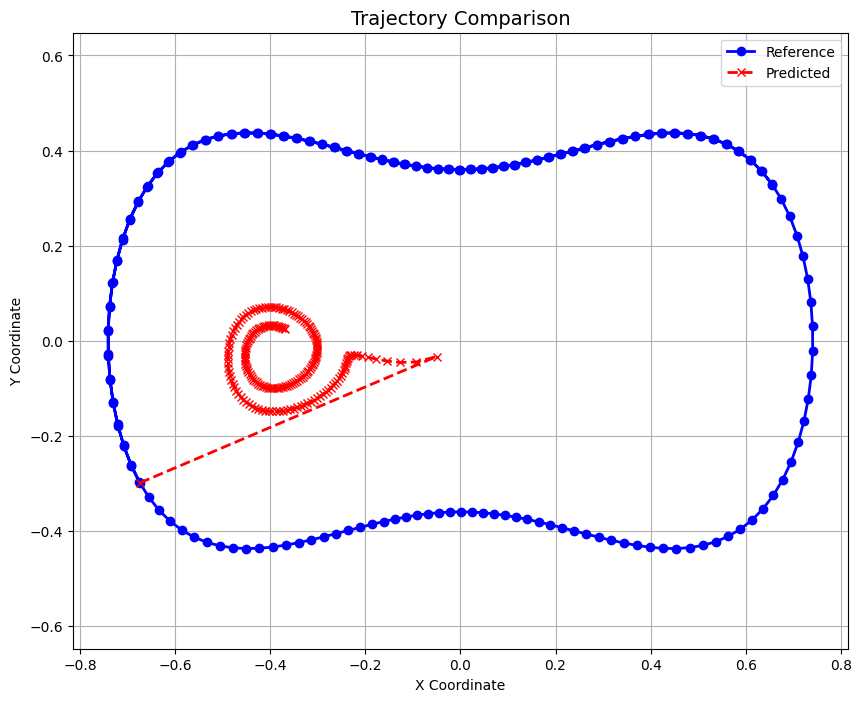

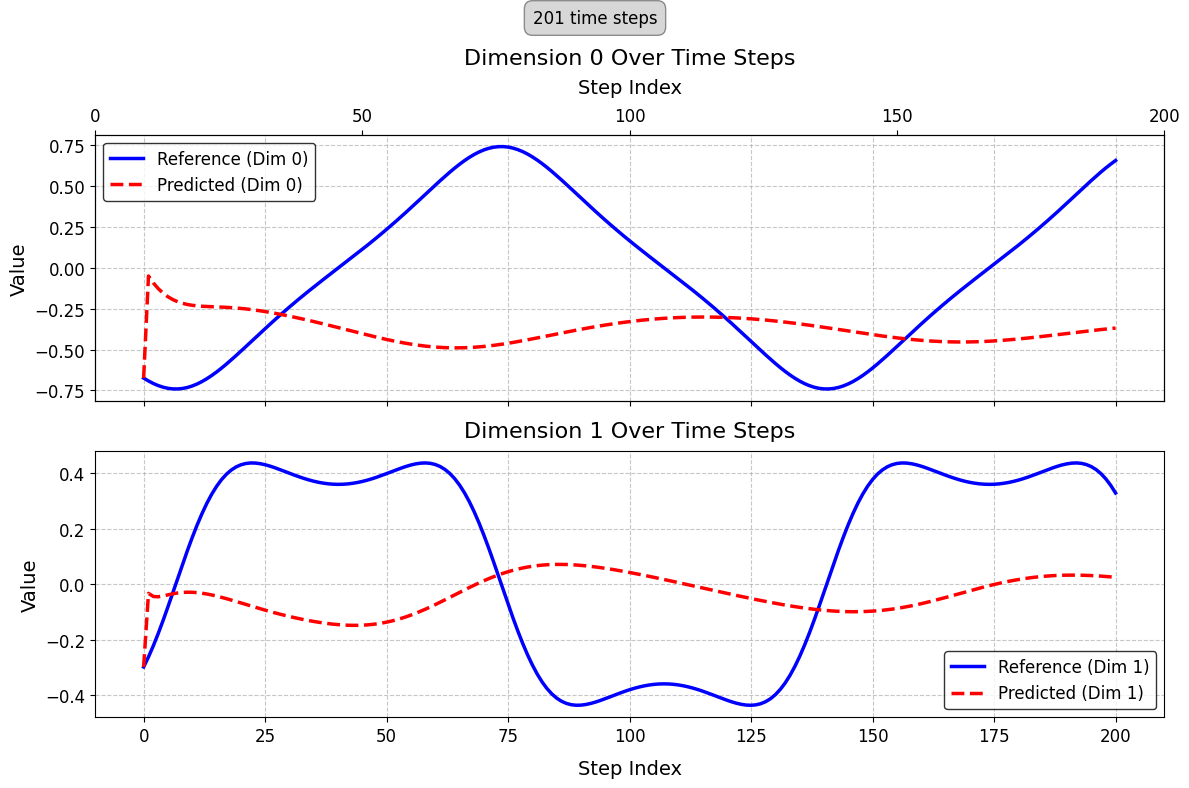

In [13]:
model.eval()
traj = preprocessed_data["Xtest"][0].to(device)

with torch.no_grad():
    reconstructed_traj, predicted_traj = None, None

    predicted_traj = trainer_EncoderDecoder.predict_traj(X0=traj[0], steps=len(traj)-1)
    predicted_traj = predicted_traj.cpu().detach().numpy()

    traj = traj.cpu().detach().numpy()

if traj.shape[1] <= 3:
    plot_trajectories(ref_trajectory=traj, pred_trajectory=predicted_traj, recon_trajectory=reconstructed_traj, folder_path=folder_path,save=False)
else:
    plot_trajectories(ref_trajectory=traj[:, :3], pred_trajectory=predicted_traj[:, :3], folder_path=folder_path,save=False)
plot_trajectory_comparison(ref_trajectory=traj, pred_trajectory=predicted_traj, recon_trajectory=reconstructed_traj, folder_path=folder_path,save=False)

### Prediction with model context

1
torch.Size([2, 2])


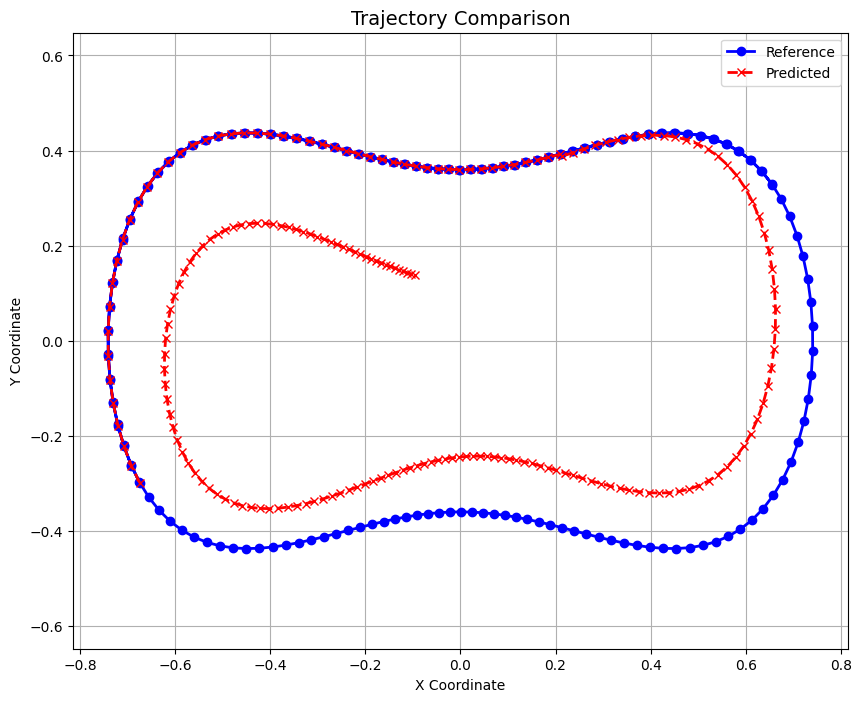

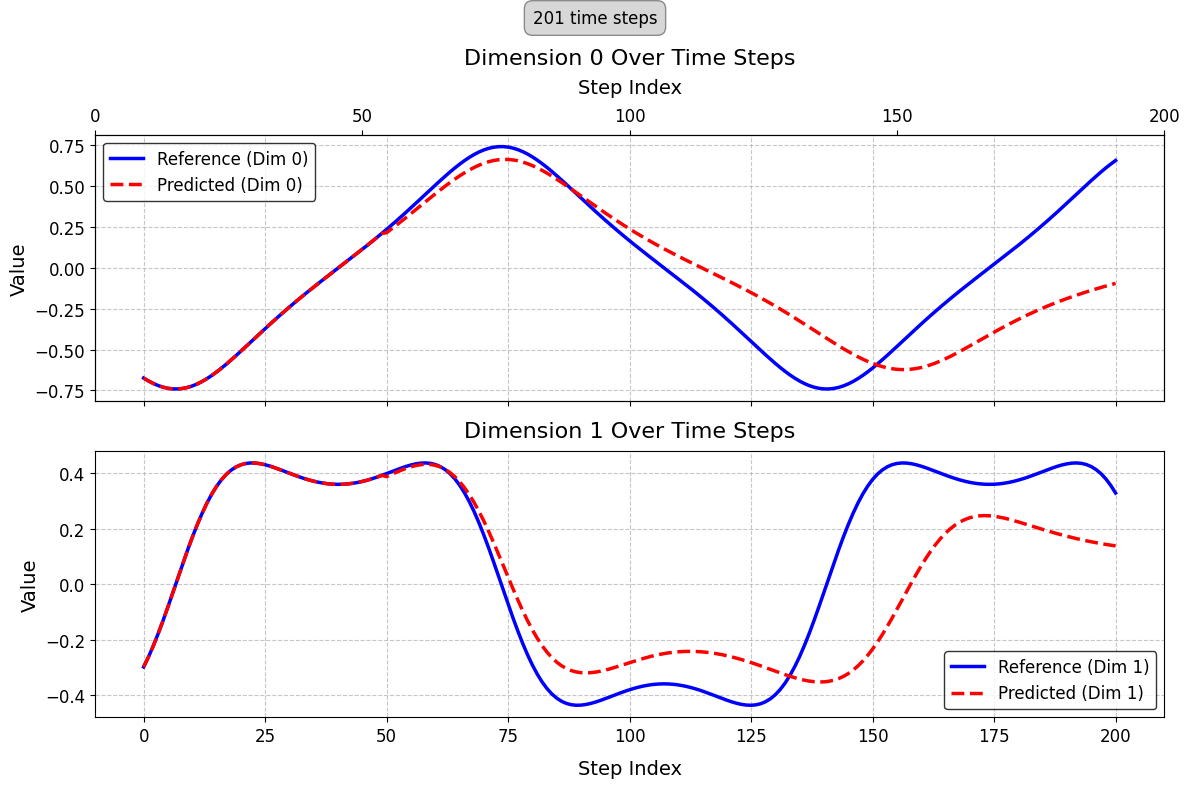

In [14]:
model.eval()
traj = preprocessed_data["Xtest"][0].to(device)

print(traj[0].ndim)
print(traj[:2].shape)
with torch.no_grad():
    reconstructed_traj, predicted_traj = None, None

    predicted_traj = trainer_EncoderDecoder.prediction_with_model_context( X0=traj[:50], steps=len(traj))
    predicted_traj = predicted_traj.cpu().detach().numpy()

    traj = traj.cpu().detach().numpy()

if traj.shape[1] <= 3:
    plot_trajectories(ref_trajectory=traj, pred_trajectory=predicted_traj, recon_trajectory=reconstructed_traj, folder_path=folder_path,save=False)
else:
    plot_trajectories(ref_trajectory=traj[:, :3], pred_trajectory=predicted_traj[:, :3], folder_path=folder_path,save=False)
plot_trajectory_comparison(ref_trajectory=traj, pred_trajectory=predicted_traj, recon_trajectory=reconstructed_traj, folder_path=folder_path,save=False)

### Prediction with customer context

1
torch.Size([2, 2])


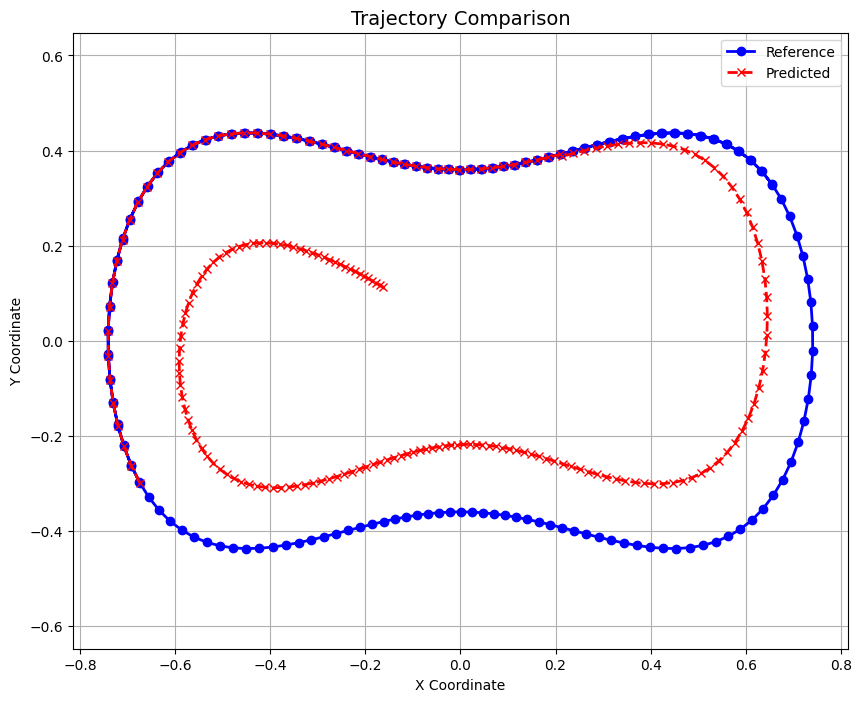

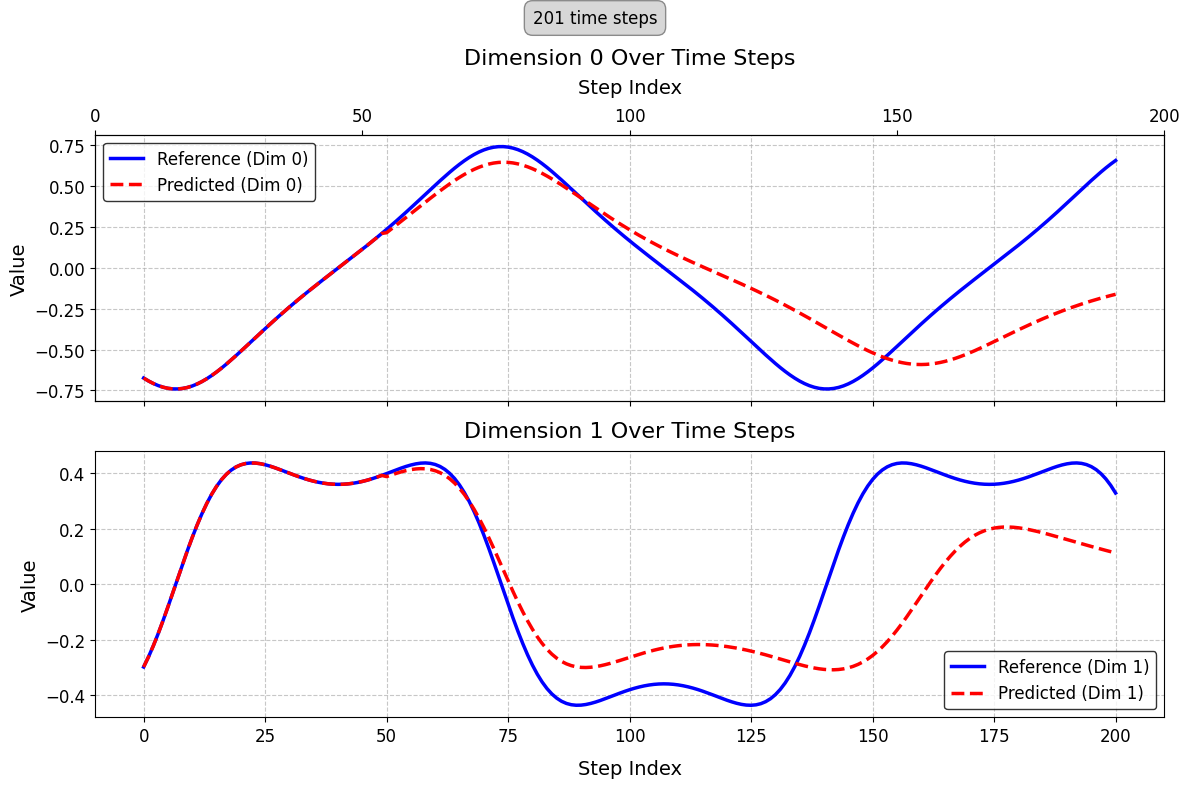

In [15]:
model.eval()
traj = preprocessed_data["Xtest"][0].to(device)

print(traj[0].ndim)
print(traj[:2].shape)
with torch.no_grad():
    reconstructed_traj, predicted_traj = None, None

    predicted_traj = trainer_EncoderDecoder.prediction_with_custom_context( X0=traj[:50], steps=len(traj), context=50)
    predicted_traj = predicted_traj.cpu().detach().numpy()

    traj = traj.cpu().detach().numpy()

if traj.shape[1] <= 3:
    plot_trajectories(ref_trajectory=traj, pred_trajectory=predicted_traj, recon_trajectory=reconstructed_traj, folder_path=folder_path,save=False)
else:
    plot_trajectories(ref_trajectory=traj[:, :3], pred_trajectory=predicted_traj[:, :3], folder_path=folder_path,save=False)
plot_trajectory_comparison(ref_trajectory=traj, pred_trajectory=predicted_traj, recon_trajectory=reconstructed_traj, folder_path=folder_path,save=False)

## Testing these models

In [16]:
def evaluate_all_methods(preprocessed_data, model, trainer, device):
    model.eval()
    # leave it as Xtest = preprocessed_data["Xtest"] if you want to evaluate on the full test set
    Xtest = preprocessed_data["Xtest"][:10]

    # Define the inference methods
    def prediction(traj):
        return trainer_EncoderDecoder.predict_traj(X0=traj[0], steps=len(traj)-1)
    
    def prediction_full_context(traj):
        return trainer_EncoderDecoder.prediction_with_model_context( X0=traj[:50], steps=len(traj))
    
    def prediction_fixed_context(traj):
        return trainer_EncoderDecoder.prediction_with_custom_context( X0=traj[:50], steps=len(traj), context=50)
    
    methods = {
        "Original Prediction": prediction,
        "Fixed Context Prediction": prediction_fixed_context,
    }


    testing_results = {}
    for name, func in methods.items():
        print(f"Evaluating method: {name}")
        result = []
        for traj in Xtest:
            traj = traj.to(device)
            predicted_traj = func(traj)
            mse_diff = torch.mean((predicted_traj - traj) ** 2).item()
            result.append(mse_diff)
        testing_results[name] = np.mean(result)


    return testing_results


# Evaluate all methods
results = evaluate_all_methods(preprocessed_data, model, trainer_EncoderDecoder, device)

print("Evaluation Results:")
for method, mse in results.items():
    print(f"{method}: MSE = {mse:.4f}")


Evaluating method: Original Prediction
Evaluating method: Fixed Context Prediction
Evaluation Results:
Original Prediction: MSE = 0.2253
Fixed Context Prediction: MSE = 0.0816
